In [1]:
# Load the three source datasets used to study funding, poverty, and achievement.
import pandas as pd

finance = pd.read_excel("../datasets/finance.xlsx")
saipe = pd.read_excel("../datasets/saipe.xlsx",skiprows=2)
edfacts_math = pd.read_csv("../datasets/math.csv",dtype=str)
edfacts_reading=pd.read_csv('../datasets/Reading.csv',dtype=str)

In [2]:
# Confirm the row and column counts before cleaning so later exclusions are traceable.
print(finance.shape)
print(saipe.shape)
print(edfacts_math.shape)
print(edfacts_reading.shape)

(19700, 262)
(13207, 7)
(1389832, 12)
(1390071, 12)


In [3]:
finance.head()

,LEAID,CENSUSID,FIPST,CONUM,CSA,CBSA,NAME,STNAME,STABBR,SCHLEV,...,FL_66V,FL_W01,FL_W31,FL_W61,FL_V95,FL_V02,FL_K14,FL_CE1,FL_CE2,FL_CE3
0,0100002,N,1,01073,142,13820,Alabama Youth Services,Alabama,AL,N,...,M,M,M,M,M,M,M,M,M,M
1,0100005,01504840100000,1,01095,290,10700,Albertville City,Alabama,AL,03,...,M,R,R,R,R,R,M,M,M,M
2,0100006,01504800100000,1,01095,290,10700,Marshall County,Alabama,AL,03,...,M,R,R,R,R,R,M,M,M,M
3,0100007,01503740100000,1,01073,142,13820,Hoover City,Alabama,AL,03,...,M,R,R,R,R,R,M,M,M,M
4,0100008,01504530100000,1,01089,290,26620,Madison City,Alabama,AL,03,...,M,R,R,R,R,R,M,M,M,M


In [4]:
saipe

,State Postal Code,State FIPS Code,District ID,Name,Estimated Total Population,Estimated Population 5-17,Estimated number of relevant children 5 to 17 years old in poverty who are related to the householder
0,AL,1,190,Alabaster City School District,34383,6709,778
1,AL,1,5,Albertville City School District,21914,4086,1228
2,AL,1,30,Alexander City City School District,16996,2598,970
3,AL,1,60,Andalusia City School District,8830,1449,452
4,AL,1,90,Anniston City School District,22163,3100,1180
...,...,...,...,...,...,...,...
13202,WY,56,6240,Washakie County School District 1,7208,1297,183
13203,WY,56,5820,Washakie County School District 2,677,90,8
13204,WY,56,4830,Weston County School District 1,5497,834,135
13205,WY,56,6090,Weston County School District 7,1470,254,15


In [5]:
edfacts_math.head(50)

,SCHOOL_YEAR,STNAM,FIPST,LEAID,ST_LEAID,LEANM,SUBJECT,GRADE,CATEGORY,DATE_CUR,NUMVALID,PCTPROF
0,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,MTH,00,MIG,13AUG20,120,15-19
1,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,MTH,03,CWD,13AUG20,46,30-39
2,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,MTH,04,MHI,13AUG20,222,30-34
3,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,MTH,03,MHI,13AUG20,252,55-59
4,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,MTH,06,HOM,13AUG20,6,LT50
5,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,MTH,04,FCS,13AUG20,1,PS
6,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,MTH,08,MBL,13AUG20,17,21-39
7,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,MTH,06,MBL,13AUG20,12,LT50
8,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,MTH,07,M,13AUG20,219,40-44
9,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,MTH,03,MBL,13AUG20,12,LT50


In [6]:
edfacts_reading.head(10)

,SCHOOL_YEAR,STNAM,FIPST,LEAID,ST_LEAID,LEANM,SUBJECT,GRADE,CATEGORY,DATE_CUR,NUMVALID,PCTPROF
0,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,RLA,05,MHI,13AUG20,218,20-24
1,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,RLA,07,ECD,13AUG20,155,25-29
2,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,RLA,04,MAM,13AUG20,3,PS
3,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,RLA,08,F,13AUG20,199,40-44
4,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,RLA,HS,MWH,13AUG20,158,40-44
5,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,RLA,HS,MIL,13AUG20,7,LT50
6,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,RLA,04,CWD,13AUG20,40,11-19
7,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,RLA,03,ALL,13AUG20,442,40
8,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,RLA,HS,FCS,13AUG20,1,PS
9,2018-2019,ALABAMA,01,0100005,AL-101,Albertville City,RLA,06,MAM,13AUG20,1,PS


In [7]:
finance.columns.tolist()

['LEAID',
 'CENSUSID',
 'FIPST',
 'CONUM',
 'CSA',
 'CBSA',
 'NAME',
 'STNAME',
 'STABBR',
 'SCHLEV',
 'AGCHRT',
 'YEAR',
 'CCDNF',
 'CENFILE',
 'GSLO',
 'GSHI',
 'V33',
 'MEMBERSCH',
 'TOTALREV',
 'TFEDREV',
 'C14',
 'C15',
 'C16',
 'C17',
 'C19',
 'B11',
 'C20',
 'C25',
 'C36',
 'B10',
 'B12',
 'B13',
 'TSTREV',
 'C01',
 'C04',
 'C05',
 'C06',
 'C07',
 'C08',
 'C09',
 'C10',
 'C11',
 'C12',
 'C13',
 'C35',
 'C38',
 'C39',
 'TLOCREV',
 'T02',
 'T06',
 'T09',
 'T15',
 'T40',
 'T99',
 'D11',
 'D23',
 'A07',
 'A08',
 'A09',
 'A11',
 'A13',
 'A15',
 'A20',
 'A40',
 'U11',
 'U22',
 'U30',
 'U50',
 'U97',
 'C24',
 'TOTALEXP',
 'TCURELSC',
 'TCURINST',
 'E13',
 'V91',
 'V92',
 'TCURSSVC',
 'E17',
 'E07',
 'E08',
 'E09',
 'V40',
 'V45',
 'V90',
 'V85',
 'TCUROTH',
 'E11',
 'V60',
 'V65',
 'TNONELSE',
 'V70',
 'V75',
 'V80',
 'TCAPOUT',
 'F12',
 'G15',
 'K09',
 'K10',
 'K11',
 'L12',
 'M12',
 'Q11',
 'I86',
 'Z32',
 'Z33',
 'Z35',
 'Z36',
 'Z37',
 'Z38',
 'V11',
 'V13',
 'V15',
 'V17',
 'V21',

In [8]:
saipe.columns.tolist()

['State Postal Code',
 'State FIPS Code',
 'District ID',
 'Name',
 'Estimated Total Population',
 'Estimated Population 5-17',
 'Estimated number of relevant children 5 to 17 years old in poverty who are related to the householder']

In [9]:
edfacts_math.columns.tolist()

['SCHOOL_YEAR',
 'STNAM',
 'FIPST',
 'LEAID',
 'ST_LEAID',
 'LEANM',
 'SUBJECT',
 'GRADE',
 'CATEGORY',
 'DATE_CUR',
 'NUMVALID',
 'PCTPROF']

In [10]:
edfacts_reading.columns.tolist()

['SCHOOL_YEAR',
 'STNAM',
 'FIPST',
 'LEAID',
 'ST_LEAID',
 'LEANM',
 'SUBJECT',
 'GRADE',
 'CATEGORY',
 'DATE_CUR',
 'NUMVALID',
 'PCTPROF']

In [11]:
edfacts_math.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389832 entries, 0 to 1389831
Data columns (total 12 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   SCHOOL_YEAR  1389832 non-null  object
 1   STNAM        1389832 non-null  object
 2   FIPST        1389832 non-null  object
 3   LEAID        1389832 non-null  object
 4   ST_LEAID     1389832 non-null  object
 5   LEANM        1389832 non-null  object
 6   SUBJECT      1389832 non-null  object
 7   GRADE        1389832 non-null  object
 8   CATEGORY     1389832 non-null  object
 9   DATE_CUR     1389832 non-null  object
 10  NUMVALID     1359050 non-null  object
 11  PCTPROF      1350928 non-null  object
dtypes: object(12)
memory usage: 127.2+ MB


## Cleaning edfacts


In [12]:
# Decision: retain only ALL and grade 00 records so each row represents the district-wide result.
# This prevents subgroup and grade-level rows from giving the same district multiple observations.
edfacts_math=edfacts_math[(edfacts_math['CATEGORY'] == 'ALL')&(edfacts_math['GRADE']=='00')]
edfacts_reading=edfacts_reading[(edfacts_reading['CATEGORY'] == 'ALL')&(edfacts_reading['GRADE']=='00')]

In [13]:
# Decision: retain both subjects but rename their measures before the merge.
# This makes it possible to compare math and reading outcomes without overwriting either result.
edfacts_reading.rename(columns={"NUMVALID": "NUMVALID_RLA",'PCTPROF':'PCTPROF_RLA'}, inplace=True)
edfacts_math.rename(columns={"NUMVALID": "NUMVALID_MTH",'PCTPROF':'PCTPROF_MTH'}, inplace=True)

In [14]:
# Decision: remove filter-only and duplicate metadata, keeping LEAID as the shared district key.
# This keeps the final table focused on variables needed for the funding-outcomes analysis.
edfacts_math.drop(columns=['CATEGORY','GRADE','SUBJECT','SCHOOL_YEAR','FIPST','DATE_CUR','STNAM','LEANM','ST_LEAID'], inplace=True)
edfacts_reading.drop(columns=['CATEGORY','GRADE','SUBJECT','DATE_CUR'], inplace=True)

In [15]:
print(edfacts_math.shape)
print(edfacts_reading.shape)

(17401, 3)
(17396, 8)


In [16]:
# Decision: use an inner join so every retained district has both math and reading results.
# Districts missing either outcome cannot support the project's two-subject comparison.
edfacts = edfacts_math.merge(edfacts_reading, on="LEAID", how="inner")

In [17]:
# Audit proficiency values because EDFacts uses suppression codes and ranges as well as numbers.
is_clean = edfacts['PCTPROF_MTH'].str.isdigit()

In [18]:
is_clean.value_counts()

PCTPROF_MTH
True     11802
False     5590
Name: count, dtype: int64

In [19]:
edfacts.loc[~is_clean, 'PCTPROF_MTH'].unique()

array(['10-14', '35-39', 'LE1', 'LE5', '30-34', 'LT50', '20-29', '45-49',
       '40-44', '20-24', '11-19', '30-39', '25-29', '6-9', '75-79',
       'LE20', '15-19', '55-59', '50-54', '40-49', '50-59', '21-39', 'PS',
       '60-64', '85-89', '70-74', '65-69', 'GE90', 'LE10', '40-59',
       '60-69', '60-79', '70-79', '90-94', '80-89', '80-84', 'GE50',
       'GE95', 'GE80'], dtype=object)

In [20]:
# Decision: convert ranges (for example, LE20 or 35-39) to their midpoints for quantitative analysis.
# Keep privacy-suppressed values (PS) missing rather than inventing results that the source withheld.
import numpy as np
import re

def convert_pctprof(val):
    val = str(val).strip()
    
    # Case 1: already clean digits
    if val.isdigit():
        return int(val)
    
    # Case 2: PS = privacy suppressed, no info
    if val == 'PS':
        return np.nan
    
    # Case 3: LE### (less than or equal to X) -> midpoint of 0 to X
    match = re.match(r'^LE(\d+)$', val)
    if match:
        x = int(match.group(1))
        return x / 2
    
    # Case 4: GE### (greater than or equal to X) -> midpoint of X to 100
    match = re.match(r'^GE(\d+)$', val)
    if match:
        x = int(match.group(1))
        return (x + 100) / 2
    
    # Case 5: LT### (less than X) -> midpoint of 0 to X
    match = re.match(r'^LT(\d+)$', val)
    if match:
        x = int(match.group(1))
        return x / 2
    
    # Case 6: plain range like "35-39"
    match = re.match(r'^(\d+)-(\d+)$', val)
    if match:
        low, high = int(match.group(1)), int(match.group(2))
        return (low + high) / 2
    
    # Anything unexpected - flag it instead of guessing
    return np.nan

In [21]:
# Create analysis-ready math proficiency estimates.
edfacts['PCTPROF_MTH_clean'] = edfacts['PCTPROF_MTH'].apply(convert_pctprof)

In [22]:
edfacts['PCTPROF_MTH_clean'].isna().sum()

np.int64(202)

In [23]:
(edfacts['PCTPROF_MTH'] == 'PS').sum()

np.int64(202)

In [24]:
# Apply the same transparent conversion rules to reading/language arts proficiency.
edfacts['PCTPROF_RLA_clean'] = edfacts['PCTPROF_RLA'].apply(convert_pctprof)
edfacts['PCTPROF_RLA_clean'].isna().sum()

np.int64(204)

In [25]:
(edfacts['PCTPROF_RLA'] == 'PS').sum()

np.int64(204)

In [26]:
edfacts.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17392 entries, 0 to 17391
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LEAID              17392 non-null  object 
 1   NUMVALID_MTH       17392 non-null  object 
 2   PCTPROF_MTH        17392 non-null  object 
 3   SCHOOL_YEAR        17392 non-null  object 
 4   STNAM              17392 non-null  object 
 5   FIPST              17392 non-null  object 
 6   ST_LEAID           17392 non-null  object 
 7   LEANM              17392 non-null  object 
 8   NUMVALID_RLA       17392 non-null  object 
 9   PCTPROF_RLA        17392 non-null  object 
 10  PCTPROF_MTH_clean  17190 non-null  float64
 11  PCTPROF_RLA_clean  17188 non-null  float64
dtypes: float64(2), object(10)
memory usage: 1.6+ MB


In [27]:
edfacts['NUMVALID_MTH'].unique()

array(['2911', '2952', '7475', ..., '161845', '2858', '2840'],
      shape=(3968,), dtype=object)

In [28]:
edfacts['NUMVALID_RLA'].unique()[:20]

array(['2869', '2938', '7442', '5867', '1064', '1234', '2566', '1607',
       '925', '897', '1404', '2211', '782', '1650', '609', '828', '3331',
       '1752', '1069', '88'], dtype=object)

In [29]:
# Convert valid-test counts to numbers; non-numeric suppression codes become missing.
edfacts['NUMVALID_MTH_clean'] = pd.to_numeric(edfacts['NUMVALID_MTH'], errors='coerce')
edfacts['NUMVALID_RLA_clean'] = pd.to_numeric(edfacts['NUMVALID_RLA'], errors='coerce')

In [30]:
edfacts['NUMVALID_MTH_clean'].isna().sum()

np.int64(0)

In [31]:
edfacts['NUMVALID_RLA_clean'].isna().sum()

np.int64(0)

## Cleaning Finance


In [32]:
finance['LEAID'].head()

0    0100002
1    0100005
2    0100006
3    0100007
4    0100008
Name: LEAID, dtype: object

In [33]:
finance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19700 entries, 0 to 19699
Columns: 262 entries, LEAID to FL_CE3
dtypes: int64(133), object(129)
memory usage: 39.4+ MB


In [34]:
finance['LEAID'].dtype

dtype('O')

In [35]:
# Decision: start with total spending, revenue, enrollment, and identifiers for the baseline model.
# The baseline tests whether spending per student relates to achievement after controlling for poverty.
# Layer 1 - baseline model columns
finance_core = finance[[
    'LEAID','SCHLEV', 'NAME', 'STNAME', 'STABBR', 'FIPST',
    'MEMBERSCH',      # enrollment - needed to calculate per-pupil spending
    'TOTALEXP',       # total expenditure
    'TOTALREV',        # total revenue
    'TFEDREV', 'TSTREV', 'TLOCREV',   # revenue by source
    'TCURINST', 'TCURSSVC', 'TCAPOUT'
]].copy()

# Decision: retain revenue and spending categories for a second, mechanism-level analysis.
# Separating instruction, support, capital, and funding sources avoids treating all dollars as equivalent.
# Layer 2 - breakdown columns (added once baseline model works)
finance_breakdown = finance[[
    'LEAID',
    'TFEDREV', 'TSTREV', 'TLOCREV',   # revenue by source
    'TCURINST', 'TCURSSVC', 'TCAPOUT' # expenditure by category
]].copy()

In [36]:
# Decision: use per-pupil expenditure instead of total spending because districts vary greatly in size.
# Dividing by enrollment compares the resources available for an average student across districts.
finance_core['per_pupil_exp'] = finance_core['TOTALEXP'] / finance_core['MEMBERSCH']

In [37]:
finance_core['per_pupil_exp'].describe()

c:\Users\Shelja\miniconda3\envs\data_analysis\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


count    1.970000e+04
mean              NaN
std               NaN
min              -inf
25%      1.025872e+04
50%      1.332973e+04
75%      1.843022e+04
max               inf
Name: per_pupil_exp, dtype: float64

In [38]:
finance_core[finance_core['MEMBERSCH']==0]

,LEAID,SCHLEV,NAME,STNAME,STABBR,FIPST,MEMBERSCH,TOTALEXP,TOTALREV,TFEDREV,TSTREV,TLOCREV,TCURINST,TCURSSVC,TCAPOUT,per_pupil_exp
492,0400453,N,Pinal County Juvenile Detention (79534),Arizona,AZ,4,0,-2,-2,-2,-2,-2,-2,-2,-2,-inf
493,0400455,N,ARIZONA STATE HOSPITAL (6415),Arizona,AZ,4,0,-2,-2,-2,-2,-2,-2,-2,-2,-inf
495,0400457,N,Cochise County Juvenile Detention (79462),Arizona,AZ,4,0,-2,-2,-2,-2,-2,-2,-2,-2,-inf
496,0400458,N,Yuma County Juvenile Justice Center (79524),Arizona,AZ,4,0,-2,-2,-2,-2,-2,-2,-2,-2,-inf
499,0400461,N,Mohave County Juvenile Detention (79589),Arizona,AZ,4,0,-2,-2,-2,-2,-2,-2,-2,-2,-inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18788,5300016,N,Centralia College,Washington,WA,53,0,-1,-1,-1,-1,-1,-1,-1,-1,-inf
18820,5300340,07,ESA 112,Washington,WA,53,0,-1,-1,-1,-1,-1,-1,-1,-1,-inf
19641,5600014,N,Normative Services - Administration Office,Wyoming,WY,56,0,-2,-2,-2,-2,-2,-2,-2,-2,-inf
19696,5680253,N,Wyoming Behavioral Institute - Administration ...,Wyoming,WY,56,0,-2,-2,-2,-2,-2,-2,-2,-2,-inf


In [39]:
finance_core[finance_core['TOTALEXP'] < 0]

,LEAID,SCHLEV,NAME,STNAME,STABBR,FIPST,MEMBERSCH,TOTALEXP,TOTALREV,TFEDREV,TSTREV,TLOCREV,TCURINST,TCURSSVC,TCAPOUT,per_pupil_exp
0,0100002,N,Alabama Youth Services,Alabama,AL,1,-2,-1,-1,-1,-1,-1,-1,-1,-1,0.500000
5,0100009,N,Al Inst Deaf And Blind,Alabama,AL,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1.000000
9,0100015,N,SafetyNet Academy Minter,Alabama,AL,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1.000000
10,0100016,N,Bryce Adolescent School,Alabama,AL,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1.000000
11,0100018,N,Alabama School of Fine Arts,Alabama,AL,1,-2,-1,-1,-1,-1,-1,-1,-1,-1,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19695,5680252,02,Youth Emergency Services Inc. - Administration...,Wyoming,WY,56,34,-2,-2,-2,-2,-2,-2,-2,-2,-0.058824
19696,5680253,N,Wyoming Behavioral Institute - Administration ...,Wyoming,WY,56,0,-2,-2,-2,-2,-2,-2,-2,-2,-inf
19697,5680254,03,Saint Stephen's Indian School Admin Office,Wyoming,WY,56,240,-2,-2,-2,-2,-2,-2,-2,-2,-0.008333
19698,5680255,02,Right of Passage,Wyoming,WY,56,29,-2,-2,-2,-2,-2,-2,-2,-2,-0.068966


In [40]:
finance_core[finance_core['TOTALEXP'] < 0]['TOTALEXP'].unique()

array([-1, -2])

In [41]:
# Decision: require positive enrollment, spending, and revenue before calculating or modeling per-pupil funding.
# Zero/negative values often identify non-operating agencies or reporting anomalies and would create misleading ratios.
finance_core_clean = finance_core[
    (finance_core['MEMBERSCH'] > 0) &
    (finance_core['TOTALEXP'] > 0) &
    (finance_core['TOTALREV'] > 0)
].copy()

In [42]:
finance_core_clean

,LEAID,SCHLEV,NAME,STNAME,STABBR,FIPST,MEMBERSCH,TOTALEXP,TOTALREV,TFEDREV,TSTREV,TLOCREV,TCURINST,TCURSSVC,TCAPOUT,per_pupil_exp
1,0100005,03,Albertville City,Alabama,AL,1,5636,55237000,60116000,7939000,36177000,16000000,28612000,17262000,2750000,9800.745209
2,0100006,03,Marshall County,Alabama,AL,1,5652,60022000,61936000,7953000,40042000,13941000,30884000,23015000,266000,10619.603680
3,0100007,03,Hoover City,Alabama,AL,1,13952,195605000,189124000,6935000,78790000,103399000,102547000,57484000,17371000,14019.853784
4,0100008,03,Madison City,Alabama,AL,1,11290,118941000,129403000,6043000,69870000,53490000,65771000,38601000,4186000,10535.075288
6,0100011,03,Leeds City,Alabama,AL,1,1950,21442000,21144000,1574000,12794000,6776000,10796000,7807000,221000,10995.897436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19687,5605762,03,Sweetwater County School District #2,Wyoming,WY,56,2544,45914000,48326000,2384000,12043000,33899000,23326000,17018000,3109000,18047.955975
19688,5605820,03,Washakie County School District #2,Wyoming,WY,56,108,3441000,3517000,108000,2432000,977000,1763000,1284000,269000,31861.111111
19689,5605830,03,Teton County School District #1,Wyoming,WY,56,2881,65828000,62685000,1626000,9101000,51958000,32894000,19052000,11924000,22849.010760
19690,5606090,03,Weston County School District #7,Wyoming,WY,56,223,6588000,6635000,124000,4932000,1579000,3134000,2598000,627000,29542.600897


In [43]:
finance_core_clean['per_pupil_exp'].describe()

count    1.698300e+04
mean     2.050843e+04
std      1.060418e+05
min      2.238255e+03
25%      1.144116e+04
50%      1.418573e+04
75%      1.934217e+04
max      1.223500e+07
Name: per_pupil_exp, dtype: float64

In [44]:
finance_core_clean.sort_values('per_pupil_exp', ascending=False).head(15)

,LEAID,SCHLEV,NAME,STNAME,STABBR,FIPST,MEMBERSCH,TOTALEXP,TOTALREV,TFEDREV,TSTREV,TLOCREV,TCURINST,TCURSSVC,TCAPOUT,per_pupil_exp
4753,1701393,07,Grundy County Spec Educ Coop,Illinois,IL,17,1,12235000,12480000,2985000,1351000,8144000,7158000,2761000,225000,1.223500e+07
11855,3480240,07,Monmouth-Ocean Educational Services Commission...,New Jersey,NJ,34,17,64812000,62318000,0,1228000,61090000,9631000,5178000,449000,3.812471e+06
4723,1700311,07,South Eastern Sp Ed Program,Illinois,IL,17,3,8137000,8215000,3528000,2095000,2592000,3214000,4208000,187000,2.712333e+06
3400,0691011,05,Inyo County Office of Education,California,CA,6,9,13212000,14105000,2737000,6171000,5197000,1497000,6797000,31000,1.468000e+06
3431,0691044,05,Trinity County Office of Education,California,CA,6,7,8513000,8698000,1814000,4715000,2169000,400000,4040000,26000,1.216143e+06
11858,3480300,07,Essex Regional Educational Services Commission,New Jersey,NJ,34,68,67551000,63876000,1425000,2354000,60097000,22161000,43224000,1915000,9.933971e+05
4560,1700051,07,Iroquois Special Education,Illinois,IL,17,10,8518000,8060000,1203000,3165000,3692000,5244000,2955000,276000,8.518000e+05
18780,5300007,07,Olympic Educational Service District 114,Washington,WA,53,18,14113000,20520000,6988000,4395000,9137000,5736000,8140000,189000,7.840556e+05
3421,0691033,05,San Mateo County Office of Education,California,CA,6,216,160518000,180897000,20475000,26881000,133541000,27824000,44042000,3009000,7.431389e+05
8798,2700083,07,REGION 4-LAKES COUNTRY SERVICE COOP,Minnesota,MN,27,57,40071000,37696000,644000,3835000,33217000,3811000,34658000,896000,7.030000e+05


In [45]:
# Decision: exclude SCHLEV codes 05, 06, 07, and N because they are not comparable regular district records.
# Keeping only district-level agencies ensures funding and proficiency are measured at the same unit of analysis.
finance_core_clean = finance_core_clean[~finance_core_clean['SCHLEV'].isin(['05', '06', '07','N'])]

In [46]:
finance_core_clean

,LEAID,SCHLEV,NAME,STNAME,STABBR,FIPST,MEMBERSCH,TOTALEXP,TOTALREV,TFEDREV,TSTREV,TLOCREV,TCURINST,TCURSSVC,TCAPOUT,per_pupil_exp
1,0100005,03,Albertville City,Alabama,AL,1,5636,55237000,60116000,7939000,36177000,16000000,28612000,17262000,2750000,9800.745209
2,0100006,03,Marshall County,Alabama,AL,1,5652,60022000,61936000,7953000,40042000,13941000,30884000,23015000,266000,10619.603680
3,0100007,03,Hoover City,Alabama,AL,1,13952,195605000,189124000,6935000,78790000,103399000,102547000,57484000,17371000,14019.853784
4,0100008,03,Madison City,Alabama,AL,1,11290,118941000,129403000,6043000,69870000,53490000,65771000,38601000,4186000,10535.075288
6,0100011,03,Leeds City,Alabama,AL,1,1950,21442000,21144000,1574000,12794000,6776000,10796000,7807000,221000,10995.897436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19687,5605762,03,Sweetwater County School District #2,Wyoming,WY,56,2544,45914000,48326000,2384000,12043000,33899000,23326000,17018000,3109000,18047.955975
19688,5605820,03,Washakie County School District #2,Wyoming,WY,56,108,3441000,3517000,108000,2432000,977000,1763000,1284000,269000,31861.111111
19689,5605830,03,Teton County School District #1,Wyoming,WY,56,2881,65828000,62685000,1626000,9101000,51958000,32894000,19052000,11924000,22849.010760
19690,5606090,03,Weston County School District #7,Wyoming,WY,56,223,6588000,6635000,124000,4932000,1579000,3134000,2598000,627000,29542.600897


In [47]:
finance_core_clean['per_pupil_exp'].describe()

count     16662.000000
mean      16656.344515
std       11036.358130
min        2238.255034
25%       11399.239544
50%       14078.927915
75%       18918.923420
max      622722.222222
Name: per_pupil_exp, dtype: float64

In [48]:
finance_core_clean.sort_values('per_pupil_exp', ascending=False).head(15)

,LEAID,SCHLEV,NAME,STNAME,STABBR,FIPST,MEMBERSCH,TOTALEXP,TOTALREV,TFEDREV,TSTREV,TLOCREV,TCURINST,TCURSSVC,TCAPOUT,per_pupil_exp
11250,3400753,02,M.E.T.S. CHARTER SCHOOL,New Jersey,NJ,34,18,11209000,11038000,640000,1025000,9373000,5650000,5544000,15000,622722.222222
4422,1600185,02,ADVANCED REGIONAL TECHNICAL EDUCATION INDUSTRI...,Idaho,ID,16,6,1809000,1864000,0,1863000,1000,1543000,106000,160000,301500.000000
4776,1701421,03,Northwest Sp Ed Cooperative,Illinois,IL,17,17,4317000,5062000,1986000,1118000,1958000,671000,1849000,12000,253941.176471
6395,2000018,03,School for Blind,Kansas,KS,20,27,6724000,6708000,695000,6011000,2000,4488000,1940000,12000,249037.037037
12605,3612400,03,GREENBURGH-GRAHAM UNION FREE SCHOOL DISTRICT,New York,NY,36,120,25115000,25198000,473000,169000,24556000,14055000,8362000,625000,209291.666667
12818,3621540,01,FIRE ISLAND UNION FREE SCHOOL DISTRICT,New York,NY,36,32,5331000,5623000,65000,397000,5161000,1842000,2882000,245000,166593.750000
12549,3610140,03,GREENBURGH ELEVEN UNION FREE SCHOOL DISTRICT,New York,NY,36,94,14909000,14672000,581000,202000,13889000,8275000,5218000,1000,158606.382979
17527,4825410,01,KENEDY COUNTY WIDE CSD,Texas,TX,48,64,9395000,9998000,15000,213000,9770000,1053000,1017000,0,146796.875000
2618,0606510,01,Burnt Ranch Elementary,California,CA,6,84,12068000,14576000,180000,13844000,552000,815000,578000,10576000,143666.666667
3675,0806300,03,Mountain Valley School District No. Re 1,Colorado,CO,8,137,19587000,20054000,344000,18427000,1283000,1234000,1187000,16909000,142970.802920


In [49]:
finance_core_clean[finance_core_clean['MEMBERSCH'] < 50].shape

(440, 16)

In [50]:
# WHY: same check we did on saipe — before trusting that all small-enrollment
# rows are real tiny districts (not data errors), inspect the smallest
# MEMBERSCH values directly and look at the Name column.

suspect_finance = finance_core_clean[finance_core_clean['MEMBERSCH'] <= 5]
print(f"Rows with MEMBERSCH <= 5: {len(suspect_finance)}")
suspect_finance[['LEAID', 'NAME', 'MEMBERSCH']].sort_values('MEMBERSCH')

Rows with MEMBERSCH <= 5: 37


,LEAID,NAME,MEMBERSCH
4509,1602730,PRAIRIE ELEMENTARY DISTRICT,1
10454,3020880,Pleasant Valley Elem,1
8228,2606300,Bois Blanc Pines School District,2
900,0407380,San Fernando Elementary District (4414),2
10280,3008040,S H Elem,2
10397,3015930,Swan Lake-Salmon Elem,2
10337,3011990,Ross Elem,2
10433,3018660,Molt Elem,2
15545,4112360,Troy SD 54,2
10442,3019530,Nye Elem,3


In [51]:
finance_core_clean['per_pupil_exp'].describe()

count     16662.000000
mean      16656.344515
std       11036.358130
min        2238.255034
25%       11399.239544
50%       14078.927915
75%       18918.923420
max      622722.222222
Name: per_pupil_exp, dtype: float64

## Saipe Cleaning


In [52]:
saipe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13207 entries, 0 to 13206
Data columns (total 7 columns):
 #   Column                                                                                                 Non-Null Count  Dtype 
---  ------                                                                                                 --------------  ----- 
 0   State Postal Code                                                                                      13207 non-null  object
 1   State FIPS Code                                                                                        13207 non-null  int64 
 2   District ID                                                                                            13207 non-null  int64 
 3   Name                                                                                                   13207 non-null  object
 4   Estimated Total Population                                                                           

In [53]:
# Decision: zero-pad FIPS components before joining them so SAIPE matches the seven-digit EDFacts/finance LEAID.
# Without padding, IDs such as state 01 would become 1 and valid districts would fail to merge.

saipe['State FIPS Code'] = saipe['State FIPS Code'].astype(str).str.zfill(2)
saipe['District ID'] = saipe['District ID'].astype(str).str.zfill(5)
saipe['LEAID'] = saipe['State FIPS Code'] + saipe['District ID']

In [54]:
saipe.head(10)

,State Postal Code,State FIPS Code,District ID,Name,Estimated Total Population,Estimated Population 5-17,Estimated number of relevant children 5 to 17 years old in poverty who are related to the householder,LEAID
0,AL,01,00190,Alabaster City School District,34383,6709,778,0100190
1,AL,01,00005,Albertville City School District,21914,4086,1228,0100005
2,AL,01,00030,Alexander City City School District,16996,2598,970,0100030
3,AL,01,00060,Andalusia City School District,8830,1449,452,0100060
4,AL,01,00090,Anniston City School District,22163,3100,1180,0100090
5,AL,01,00100,Arab City School District,8349,1507,264,0100100
6,AL,01,00120,Athens City School District,25416,3971,708,0100120
7,AL,01,00180,Attalla City School District,5936,913,238,0100180
8,AL,01,00210,Auburn City School District,62449,7428,870,0100210
9,AL,01,00240,Autauga County School District,55601,9799,1891,0100240


In [55]:
# Decision: use the child poverty rate—not a raw poverty count—to compare districts of different sizes.
# This is the control variable that separates the relationship between funding and achievement from community wealth.
saipe['poverty_rate'] = (saipe['Estimated number of relevant children 5 to 17 years old in poverty who are related to the householder'] 
                          / saipe['Estimated Population 5-17']) * 100

In [56]:
saipe['poverty_rate'].describe()

count    13198.000000
mean        16.350285
std          9.359086
min          0.000000
25%          9.354759
50%         14.854592
75%         21.577679
max        100.000000
Name: poverty_rate, dtype: float64

In [57]:
saipe[saipe['poverty_rate'].isna()]

,State Postal Code,State FIPS Code,District ID,Name,Estimated Total Population,Estimated Population 5-17,Estimated number of relevant children 5 to 17 years old in poverty who are related to the householder,LEAID,poverty_rate
212,AZ,04,01230,Blue Elementary District,43,0,0,0401230,NaN
345,AZ,04,07140,Rucker Elementary District,26,0,0,0407140,NaN
4384,ME,23,06030,Glenwood Plantation,3,0,0,2306030,NaN
4405,ME,23,07110,Kingsbury Plantation,27,0,0,2307110,NaN
4407,ME,23,82007,Knox Unorganized Territory,1,0,0,2382007,NaN
4413,ME,23,82006,Lincoln Unorganized Territory,1,0,0,2382006,NaN
4417,ME,23,82013,Louds Island Unorganized Territory,0,0,0,2382013,NaN
4484,ME,23,82004,Sagadahoc Unorganized Territory,0,0,0,2382004,NaN
9284,OH,39,04896,North Bass Local School District,0,0,0,3904896,NaN


In [58]:
# Decision: remove districts with no school-age population because a poverty rate cannot be calculated for them.
saipe = saipe[saipe['Estimated Population 5-17'] > 0]

In [59]:
# WHY: before deciding whether population=1 (and similarly tiny) rows are
# real tiny districts or data errors, we need to actually look at them —
# filtering blind risks either keeping garbage rows in df, or deleting
# real small districts we said we wanted to preserve for clustering.

suspect_rows = saipe[saipe['Estimated Population 5-17'] <= 5]
print(f"Rows with population 5-17 <= 5: {len(suspect_rows)}")
suspect_rows[['LEAID', 'Name', 'Estimated Population 5-17']]  # adjust column names to match your saipe df

Rows with population 5-17 <= 5: 25


,LEAID,Name,Estimated Population 5-17
249,0402710,Eagle Elementary District,4
391,0409030,Walnut Grove Elementary District,1
4328,2302980,Beddington,3
4336,2314811,Brighton Plantation,4
4345,2300061,Caratunk,3
4364,2304897,Dennistown Plantation,3
4412,2307440,Lincoln Plantation,2
4431,2314836,Moro Plantation Public Schools,2
4542,2300057,Seboeis Plantation,1
4553,2300052,The Forks Plantation,2


In [60]:
# Keep only the identifier, district name, and poverty measure needed for the final dataset.
saipe_core = saipe[['LEAID', 'Name', 'poverty_rate','Estimated Population 5-17']].copy()

In [61]:
print(saipe_core.shape)

(13198, 4)


## MERGE

In [62]:
# Decision: use an inner join so each final district has both outcomes and valid funding data.
# This prevents a regression from mixing observed scores with missing or unmatched finance records.
df = edfacts.merge(finance_core_clean, on='LEAID', how='inner')

In [63]:
df

,LEAID,NUMVALID_MTH,PCTPROF_MTH,SCHOOL_YEAR,STNAM,FIPST_x,ST_LEAID,LEANM,NUMVALID_RLA,PCTPROF_RLA,...,MEMBERSCH,TOTALEXP,TOTALREV,TFEDREV,TSTREV,TLOCREV,TCURINST,TCURSSVC,TCAPOUT,per_pupil_exp
0,0100005,2911,46,2018-2019,ALABAMA,01,AL-101,Albertville City,2869,38,...,5636,55237000,60116000,7939000,36177000,16000000,28612000,17262000,2750000,9800.745209
1,0100006,2952,40,2018-2019,ALABAMA,01,AL-048,Marshall County,2938,36,...,5652,60022000,61936000,7953000,40042000,13941000,30884000,23015000,266000,10619.603680
2,0100007,7475,70,2018-2019,ALABAMA,01,AL-158,Hoover City,7442,65,...,13952,195605000,189124000,6935000,78790000,103399000,102547000,57484000,17371000,14019.853784
3,0100008,5903,76,2018-2019,ALABAMA,01,AL-169,Madison City,5867,73,...,11290,118941000,129403000,6043000,69870000,53490000,65771000,38601000,4186000,10535.075288
4,0100011,1063,45,2018-2019,ALABAMA,01,AL-167,Leeds City,1064,42,...,1950,21442000,21144000,1574000,12794000,6776000,10796000,7807000,221000,10995.897436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16380,5605762,1603,60,2018-2019,WYOMING,56,WY-1902000,Sweetwater County School District #2,1601,61,...,2544,45914000,48326000,2384000,12043000,33899000,23326000,17018000,3109000,18047.955975
16381,5605820,66,50-54,2018-2019,WYOMING,56,WY-2202000,Washakie County School District #2,66,55-59,...,108,3441000,3517000,108000,2432000,977000,1763000,1284000,269000,31861.111111
16382,5605830,1789,54,2018-2019,WYOMING,56,WY-2001000,Teton County School District #1,1775,61,...,2881,65828000,62685000,1626000,9101000,51958000,32894000,19052000,11924000,22849.010760
16383,5606090,144,40-44,2018-2019,WYOMING,56,WY-2307000,Weston County School District #7,144,45-49,...,223,6588000,6635000,124000,4932000,1579000,3134000,2598000,627000,29542.600897


In [64]:
# Decision: add SAIPE poverty only for districts matched across all three government sources.
# A common LEAID makes each final row a single district with funding, poverty, and achievement measures.
df = df.merge(saipe_core, on='LEAID', how='inner')

In [65]:
df

,LEAID,NUMVALID_MTH,PCTPROF_MTH,SCHOOL_YEAR,STNAM,FIPST_x,ST_LEAID,LEANM,NUMVALID_RLA,PCTPROF_RLA,...,TFEDREV,TSTREV,TLOCREV,TCURINST,TCURSSVC,TCAPOUT,per_pupil_exp,Name,poverty_rate,Estimated Population 5-17
0,0100005,2911,46,2018-2019,ALABAMA,01,AL-101,Albertville City,2869,38,...,7939000,36177000,16000000,28612000,17262000,2750000,9800.745209,Albertville City School District,30.053842,4086
1,0100006,2952,40,2018-2019,ALABAMA,01,AL-048,Marshall County,2938,36,...,7953000,40042000,13941000,30884000,23015000,266000,10619.603680,Marshall County School District,26.622181,8692
2,0100007,7475,70,2018-2019,ALABAMA,01,AL-158,Hoover City,7442,65,...,6935000,78790000,103399000,102547000,57484000,17371000,14019.853784,Hoover City School District,7.259553,14629
3,0100008,5903,76,2018-2019,ALABAMA,01,AL-169,Madison City,5867,73,...,6043000,69870000,53490000,65771000,38601000,4186000,10535.075288,Madison City School District,8.298157,9713
4,0100011,1063,45,2018-2019,ALABAMA,01,AL-167,Leeds City,1064,42,...,1574000,12794000,6776000,10796000,7807000,221000,10995.897436,Leeds City School District,16.887608,1735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12847,5605762,1603,60,2018-2019,WYOMING,56,WY-1902000,Sweetwater County School District #2,1601,61,...,2384000,12043000,33899000,23326000,17018000,3109000,18047.955975,Sweetwater County School District 2,7.748009,2762
12848,5605820,66,50-54,2018-2019,WYOMING,56,WY-2202000,Washakie County School District #2,66,55-59,...,108000,2432000,977000,1763000,1284000,269000,31861.111111,Washakie County School District 2,8.888889,90
12849,5605830,1789,54,2018-2019,WYOMING,56,WY-2001000,Teton County School District #1,1775,61,...,1626000,9101000,51958000,32894000,19052000,11924000,22849.010760,Teton County School District 1,5.793370,3107
12850,5606090,144,40-44,2018-2019,WYOMING,56,WY-2307000,Weston County School District #7,144,45-49,...,124000,4932000,1579000,3134000,2598000,627000,29542.600897,Weston County School District 7,5.905512,254


In [66]:
df.columns.tolist()

['LEAID',
 'NUMVALID_MTH',
 'PCTPROF_MTH',
 'SCHOOL_YEAR',
 'STNAM',
 'FIPST_x',
 'ST_LEAID',
 'LEANM',
 'NUMVALID_RLA',
 'PCTPROF_RLA',
 'PCTPROF_MTH_clean',
 'PCTPROF_RLA_clean',
 'NUMVALID_MTH_clean',
 'NUMVALID_RLA_clean',
 'SCHLEV',
 'NAME',
 'STNAME',
 'STABBR',
 'FIPST_y',
 'MEMBERSCH',
 'TOTALEXP',
 'TOTALREV',
 'TFEDREV',
 'TSTREV',
 'TLOCREV',
 'TCURINST',
 'TCURSSVC',
 'TCAPOUT',
 'per_pupil_exp',
 'Name',
 'poverty_rate',
 'Estimated Population 5-17']

In [67]:
# Verify that the joins preserved one row per district.
df['LEAID'].duplicated().sum()

np.int64(0)

In [68]:
# Validate that state FIPS codes agree across the achievement and finance sources.
(df['FIPST_x'] == df['FIPST_y']).all()

np.False_

In [69]:
df[df['FIPST_x'] != df['FIPST_y']][['LEAID', 'STNAM', 'STNAME', 'FIPST_x', 'FIPST_y']]

,LEAID,STNAM,STNAME,FIPST_x,FIPST_y
0,0100005,ALABAMA,Alabama,01,1
1,0100006,ALABAMA,Alabama,01,1
2,0100007,ALABAMA,Alabama,01,1
3,0100008,ALABAMA,Alabama,01,1
4,0100011,ALABAMA,Alabama,01,1
...,...,...,...,...,...
12847,5605762,WYOMING,Wyoming,56,56
12848,5605820,WYOMING,Wyoming,56,56
12849,5605830,WYOMING,Wyoming,56,56
12850,5606090,WYOMING,Wyoming,56,56


In [70]:
# Keep one validated state code and remove the duplicate created by the merge.
df = df.drop(columns=['FIPST_y'])
df = df.rename(columns={'FIPST_x': 'FIPST'})

In [71]:
# Remove duplicate district and state names from the merged sources.
df = df.drop(columns=['STNAME'])
df = df.drop(columns=['NAME', 'Name'])

In [72]:
# Standardize the remaining state-name field for readability.
df = df.rename(columns={'STNAM': 'STNAME'})

In [73]:
df.columns.tolist()

['LEAID',
 'NUMVALID_MTH',
 'PCTPROF_MTH',
 'SCHOOL_YEAR',
 'STNAME',
 'FIPST',
 'ST_LEAID',
 'LEANM',
 'NUMVALID_RLA',
 'PCTPROF_RLA',
 'PCTPROF_MTH_clean',
 'PCTPROF_RLA_clean',
 'NUMVALID_MTH_clean',
 'NUMVALID_RLA_clean',
 'SCHLEV',
 'STABBR',
 'MEMBERSCH',
 'TOTALEXP',
 'TOTALREV',
 'TFEDREV',
 'TSTREV',
 'TLOCREV',
 'TCURINST',
 'TCURSSVC',
 'TCAPOUT',
 'per_pupil_exp',
 'poverty_rate',
 'Estimated Population 5-17']

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12852 entries, 0 to 12851
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   LEAID                      12852 non-null  object 
 1   NUMVALID_MTH               12852 non-null  object 
 2   PCTPROF_MTH                12852 non-null  object 
 3   SCHOOL_YEAR                12852 non-null  object 
 4   STNAME                     12852 non-null  object 
 5   FIPST                      12852 non-null  object 
 6   ST_LEAID                   12852 non-null  object 
 7   LEANM                      12852 non-null  object 
 8   NUMVALID_RLA               12852 non-null  object 
 9   PCTPROF_RLA                12852 non-null  object 
 10  PCTPROF_MTH_clean          12769 non-null  float64
 11  PCTPROF_RLA_clean          12768 non-null  float64
 12  NUMVALID_MTH_clean         12852 non-null  int64  
 13  NUMVALID_RLA_clean         12852 non-null  int

In [75]:
df[df['PCTPROF_MTH_clean'].isna()]

,LEAID,NUMVALID_MTH,PCTPROF_MTH,SCHOOL_YEAR,STNAME,FIPST,ST_LEAID,LEANM,NUMVALID_RLA,PCTPROF_RLA,...,TOTALREV,TFEDREV,TSTREV,TLOCREV,TCURINST,TCURSSVC,TCAPOUT,per_pupil_exp,poverty_rate,Estimated Population 5-17
189,0400750,5,PS,2018-2019,ARIZONA,04,AZ-4178,Apache Elementary District (4178),5,PS,...,208000,47000,55000,106000,88000,117000,7000,42400.000000,40.909091,22
224,0402460,1,PS,2018-2019,ARIZONA,04,AZ-4483,Crown King Elementary District (4483),1,PS,...,142000,32000,12000,98000,59000,63000,5000,42333.333333,14.285714,14
349,0408460,5,PS,2018-2019,ARIZONA,04,AZ-4482,Hillside Elementary District (4482),5,PS,...,306000,19000,43000,244000,131000,60000,0,38200.000000,13.636364,22
360,0408910,3,PS,2018-2019,ARIZONA,04,AZ-4190,Valley Union High School District (4190),3,PS,...,2200000,91000,434000,1675000,959000,889000,340000,17661.417323,7.602339,171
835,0609240,3,PS,2018-2019,CALIFORNIA,06,CA-5371670,Coffee Creek Elementary,3,PS,...,232000,23000,126000,83000,159000,113000,0,30888.888889,18.181818,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9921,4111910,3,PS,2018-2019,OREGON,41,OR-00000000002018,Suntex SD 10,3,PS,...,331000,30000,256000,45000,102000,125000,9000,39333.333333,18.181818,11
9926,4112360,2,PS,2018-2019,OREGON,41,OR-00000000002222,Troy SD 54,2,PS,...,289000,9000,191000,89000,117000,66000,0,91500.000000,0.000000,2
11112,4817400,5,PS,2018-2019,TEXAS,48,TX-086024,DOSS CONSOLIDATED CSD,5,PS,...,598000,0,118000,480000,268000,265000,40000,32050.000000,6.250000,48
12277,5308370,2,PS,2018-2019,WASHINGTON,53,WA-11054,Star School District No. 054,2,PS,...,745000,0,729000,16000,172000,182000,283000,58181.818182,12.500000,16


In [76]:
df[df['PCTPROF_RLA_clean'].isna()]

,LEAID,NUMVALID_MTH,PCTPROF_MTH,SCHOOL_YEAR,STNAME,FIPST,ST_LEAID,LEANM,NUMVALID_RLA,PCTPROF_RLA,...,TOTALREV,TFEDREV,TSTREV,TLOCREV,TCURINST,TCURSSVC,TCAPOUT,per_pupil_exp,poverty_rate,Estimated Population 5-17
189,0400750,5,PS,2018-2019,ARIZONA,04,AZ-4178,Apache Elementary District (4178),5,PS,...,208000,47000,55000,106000,88000,117000,7000,42400.000000,40.909091,22
224,0402460,1,PS,2018-2019,ARIZONA,04,AZ-4483,Crown King Elementary District (4483),1,PS,...,142000,32000,12000,98000,59000,63000,5000,42333.333333,14.285714,14
349,0408460,5,PS,2018-2019,ARIZONA,04,AZ-4482,Hillside Elementary District (4482),5,PS,...,306000,19000,43000,244000,131000,60000,0,38200.000000,13.636364,22
360,0408910,3,PS,2018-2019,ARIZONA,04,AZ-4190,Valley Union High School District (4190),3,PS,...,2200000,91000,434000,1675000,959000,889000,340000,17661.417323,7.602339,171
742,0604890,6,LT50,2018-2019,CALIFORNIA,06,CA-1262695,Big Lagoon Union Elementary,3,PS,...,611000,43000,334000,234000,218000,307000,6000,29947.368421,9.090909,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9921,4111910,3,PS,2018-2019,OREGON,41,OR-00000000002018,Suntex SD 10,3,PS,...,331000,30000,256000,45000,102000,125000,9000,39333.333333,18.181818,11
9926,4112360,2,PS,2018-2019,OREGON,41,OR-00000000002222,Troy SD 54,2,PS,...,289000,9000,191000,89000,117000,66000,0,91500.000000,0.000000,2
11112,4817400,5,PS,2018-2019,TEXAS,48,TX-086024,DOSS CONSOLIDATED CSD,5,PS,...,598000,0,118000,480000,268000,265000,40000,32050.000000,6.250000,48
12277,5308370,2,PS,2018-2019,WASHINGTON,53,WA-11054,Star School District No. 054,2,PS,...,745000,0,729000,16000,172000,182000,283000,58181.818182,12.500000,16


In [77]:
# Decision: retain districts with usable math and reading proficiency estimates in both subjects.
# Privacy-suppressed outcomes cannot be reliably modeled, so they are excluded rather than estimated.
df = df.dropna(subset=['PCTPROF_MTH_clean', 'PCTPROF_RLA_clean'])

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12768 entries, 0 to 12851
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   LEAID                      12768 non-null  object 
 1   NUMVALID_MTH               12768 non-null  object 
 2   PCTPROF_MTH                12768 non-null  object 
 3   SCHOOL_YEAR                12768 non-null  object 
 4   STNAME                     12768 non-null  object 
 5   FIPST                      12768 non-null  object 
 6   ST_LEAID                   12768 non-null  object 
 7   LEANM                      12768 non-null  object 
 8   NUMVALID_RLA               12768 non-null  object 
 9   PCTPROF_RLA                12768 non-null  object 
 10  PCTPROF_MTH_clean          12768 non-null  float64
 11  PCTPROF_RLA_clean          12768 non-null  float64
 12  NUMVALID_MTH_clean         12768 non-null  int64  
 13  NUMVALID_RLA_clean         12768 non-null  int64  


In [79]:
print(df.columns.tolist())

['LEAID', 'NUMVALID_MTH', 'PCTPROF_MTH', 'SCHOOL_YEAR', 'STNAME', 'FIPST', 'ST_LEAID', 'LEANM', 'NUMVALID_RLA', 'PCTPROF_RLA', 'PCTPROF_MTH_clean', 'PCTPROF_RLA_clean', 'NUMVALID_MTH_clean', 'NUMVALID_RLA_clean', 'SCHLEV', 'STABBR', 'MEMBERSCH', 'TOTALEXP', 'TOTALREV', 'TFEDREV', 'TSTREV', 'TLOCREV', 'TCURINST', 'TCURSSVC', 'TCAPOUT', 'per_pupil_exp', 'poverty_rate', 'Estimated Population 5-17']


In [80]:
df[['NUMVALID_MTH','NUMVALID_MTH_clean','NUMVALID_RLA','NUMVALID_RLA_clean','MEMBERSCH']]

,NUMVALID_MTH,NUMVALID_MTH_clean,NUMVALID_RLA,NUMVALID_RLA_clean,MEMBERSCH
0,2911,2911,2869,2869,5636
1,2952,2952,2938,2938,5652
2,7475,7475,7442,7442,13952
3,5903,5903,5867,5867,11290
4,1063,1063,1064,1064,1950
...,...,...,...,...,...
12847,1603,1603,1601,1601,2544
12848,66,66,66,66,108
12849,1789,1789,1775,1775,2881
12850,144,144,144,144,223


In [81]:
# Drop original text fields after retaining their numeric cleaned counterparts.
df = df.drop(columns=['NUMVALID_MTH', 'NUMVALID_RLA'])

In [82]:
df['SCHLEV'].value_counts()

SCHLEV
03    10290
01     2126
02      352
Name: count, dtype: int64

In [83]:
# Remove raw and duplicate fields so the final table contains only analysis-ready variables.
df = df.drop(columns=['PCTPROF_MTH', 'PCTPROF_RLA', 'SCHOOL_YEAR', 'ST_LEAID', 'STABBR'])

## Phase 2: Descriptive Statistics

In [84]:
# Summarize the central tendency and spread of the key analysis variables.
df[['per_pupil_exp','poverty_rate','PCTPROF_MTH_clean','PCTPROF_RLA_clean']].describe()

,per_pupil_exp,poverty_rate,PCTPROF_MTH_clean,PCTPROF_RLA_clean
count,12768.000000,12768.000000,12768.000000,12768.000000
mean,17263.895451,16.278333,44.763354,50.053846
std,8722.751547,9.238901,17.773037,16.442106
min,4604.904632,0.000000,0.500000,0.500000
25%,12082.410553,9.311552,32.000000,38.000000
50%,14796.003981,14.798611,44.000000,49.500000
75%,19842.636999,21.510732,57.000000,62.000000
max,166593.750000,100.000000,96.000000,95.000000


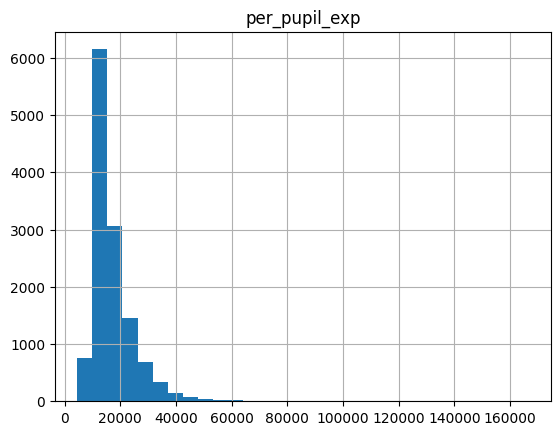

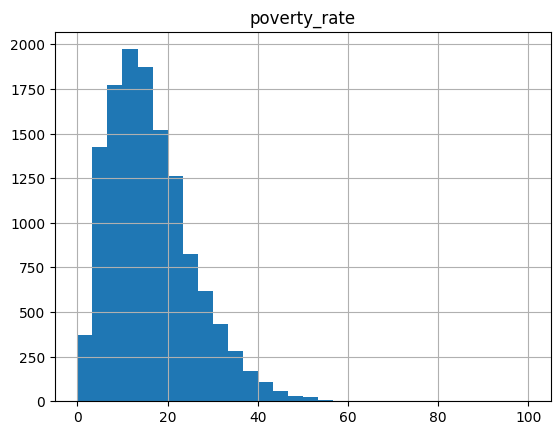

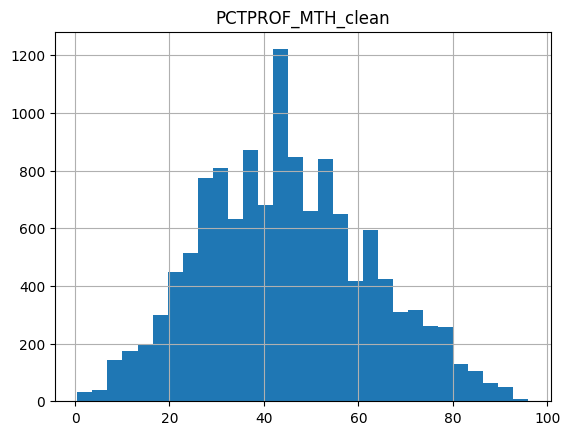

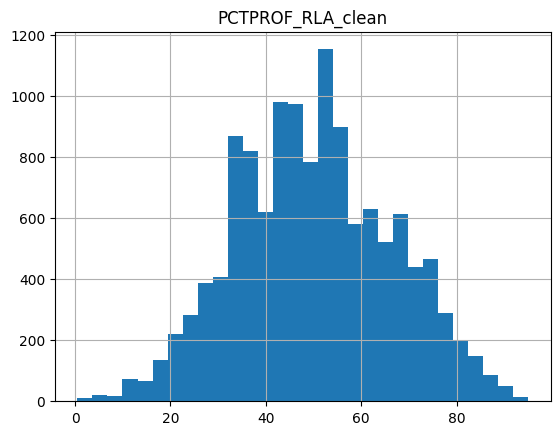

In [85]:
# Check distributions before regression, especially the right tail in per-pupil spending.
# Outliers can disproportionately influence results and should be documented or treated in later modeling.
import matplotlib.pyplot as plt

for col in ['per_pupil_exp','poverty_rate','PCTPROF_MTH_clean','PCTPROF_RLA_clean']:
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

In [86]:
# Measure pairwise linear relationships among funding, poverty, and achievement metrics.
df[['per_pupil_exp','poverty_rate','PCTPROF_MTH_clean','PCTPROF_RLA_clean']].corr()

,per_pupil_exp,poverty_rate,PCTPROF_MTH_clean,PCTPROF_RLA_clean
per_pupil_exp,1.000000,-0.134435,0.055400,0.094575
poverty_rate,-0.134435,1.000000,-0.469086,-0.534455
PCTPROF_MTH_clean,0.055400,-0.469086,1.000000,0.851235
PCTPROF_RLA_clean,0.094575,-0.534455,0.851235,1.000000


In [87]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# df is the full, untouched master dataset (all districts, all merged
# sources). It stays exactly as-is because Power BI and clustering
# (Phase 4.5) need the real, complete picture — including small or
# unusual districts, since "small district + high per-pupil spending"
# is a genuine pattern worth discovering, not something to hide.
#
# df_regression is a SEPARATE branch, built only for Phase 3/4 models.
# Regression needs filtering because unstable small-denominator values
# (tiny enrollment, tiny population estimates) can distort coefficients
# in ways that don't reflect a real relationship — they're statistical
# noise, not signal.
#
# TWO different filters are combined here, for two different reasons:
#
# 1) MEMBERSCH >= 100 (finance/enrollment)
#    Small districts can have genuinely inflated per-pupil spending
#    because fixed costs (one building, one bus, one principal) get
#    divided across very few students. Real pattern — but it destabilizes
#    a regression coefficient, so it's excluded here only, not from df.
#
# 2) Estimated Population 5-17 >= 100 (saipe/poverty)
#    SAIPE poverty rates are statistical estimates, not raw counts.
#    The Census Bureau itself publishes wider margins of error for
#    small-population districts, since a rate built on e.g. 40 kids
#    is inherently noisy. This is closer to "unreliable estimate"
#    than "real extreme value" — so it's filtered for regression too.
#
# Both conditions are applied together with & so a district must pass
# BOTH stability checks to be included in df_regression.
# ------------------------------------------------------------------

# NOTE: adjust 'Estimated Population 5-17' below to match whatever this
# column is actually named in df after the merge (check df.columns if unsure)

df_regression = df[
    (df['MEMBERSCH'] >= 100) &
    (df['Estimated Population 5-17'] >= 100)
].copy()

# ------------------------------------------------------------------
# WHY: even after removing small-denominator districts, a handful of
# remaining districts can still have extreme per-pupil spending values
# that would disproportionately swing regression coefficients.
# Capping at the 99th percentile keeps those districts IN the model
# (so we don't lose sample size) but limits how much leverage any
# single extreme value can have. This only touches df_regression —
# the full df keeps real, uncapped values for Power BI and clustering.
# ------------------------------------------------------------------

cap_value = df_regression['per_pupil_exp'].quantile(0.99)
df_regression['per_pupil_exp_capped'] = df_regression['per_pupil_exp'].clip(upper=cap_value)

print(f"Full dataset (df): {df.shape[0]} rows — for Power BI + clustering")
print(f"Regression dataset (df_regression): {df_regression.shape[0]} rows — for Phase 3/4 models only")

Full dataset (df): 12768 rows — for Power BI + clustering
Regression dataset (df_regression): 11984 rows — for Phase 3/4 models only


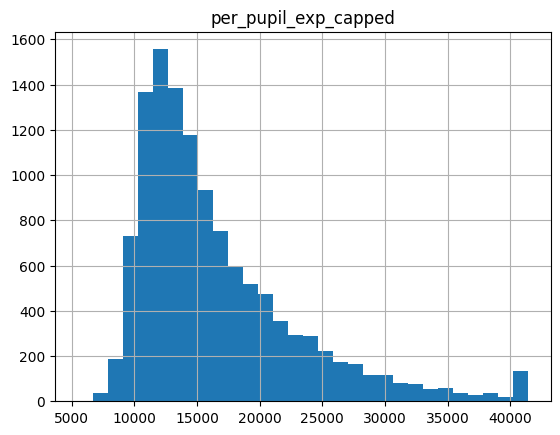

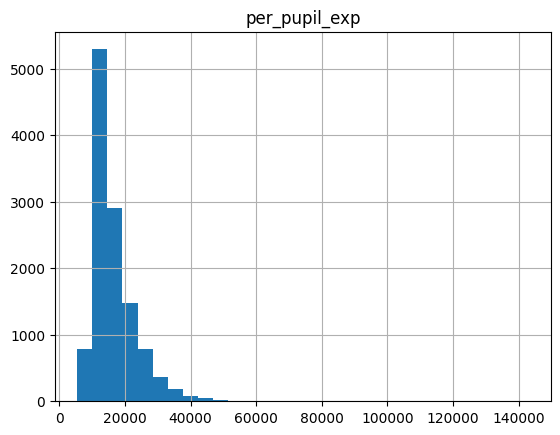

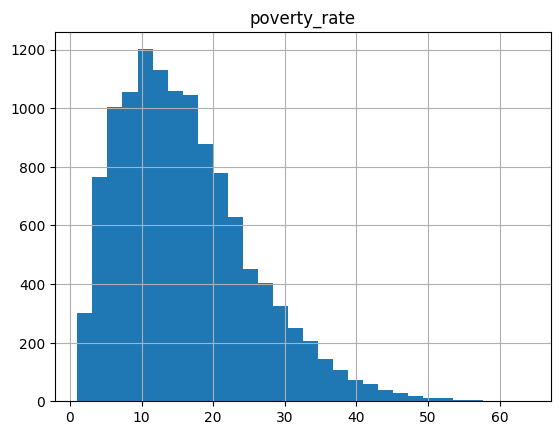

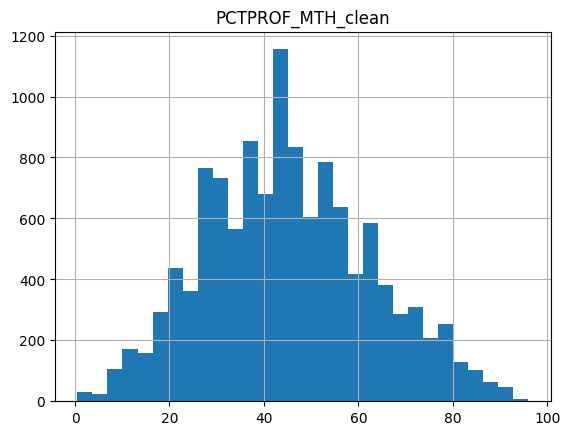

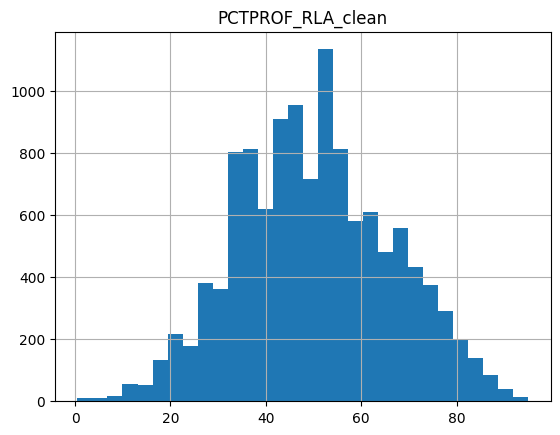

In [88]:
# WHY: check distribution shape of key regression variables before modeling.
# per_pupil_exp was right-skewed (fixed costs in small districts) -> capped at 99th pct.
# poverty_rate: normal right-skew, no outliers, no fix needed.
# PCTPROF_MTH_clean / PCTPROF_RLA_clean: roughly bell-shaped, centered ~40-50%, clean.
# No 0%/100% spikes -> no suppressed/placeholder values. All 4 vars OK for regression as-is.

for col in ['per_pupil_exp_capped','per_pupil_exp','poverty_rate','PCTPROF_MTH_clean','PCTPROF_RLA_clean']:
    df_regression[col].hist(bins=30)
    plt.title(col)
    plt.show()

                   per_pupil_exp  poverty_rate  PCTPROF_MTH_clean  \
per_pupil_exp           1.000000     -0.134435           0.055400   
poverty_rate           -0.134435      1.000000          -0.469086   
PCTPROF_MTH_clean       0.055400     -0.469086           1.000000   
PCTPROF_RLA_clean       0.094575     -0.534455           0.851235   

                   PCTPROF_RLA_clean  
per_pupil_exp               0.094575  
poverty_rate               -0.534455  
PCTPROF_MTH_clean           0.851235  
PCTPROF_RLA_clean           1.000000  


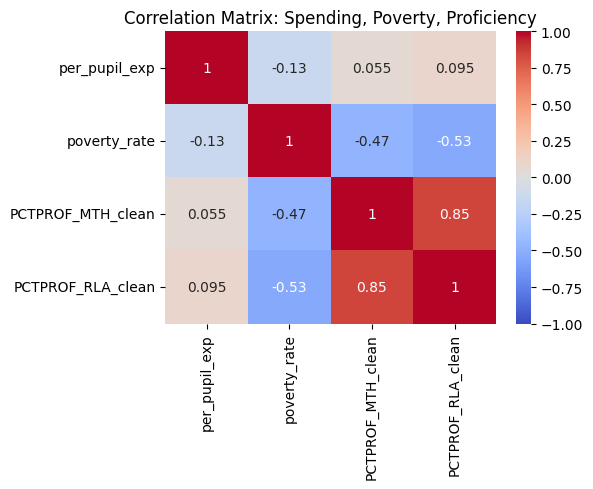

In [89]:
# WHY: Before running any regression, we check how spending, poverty, 
# and proficiency move together. This gives an early sanity check —
# e.g. if poverty and proficiency aren't even correlated, something's
# wrong upstream (bad merge, wrong columns) before we waste time modeling.

import matplotlib.pyplot as plt
import seaborn as sns

# Select only the numeric columns relevant to your question
cols_of_interest = ['per_pupil_exp', 'poverty_rate', 'PCTPROF_MTH_clean', 'PCTPROF_RLA_clean']

corr_matrix = df[cols_of_interest].corr()
print(corr_matrix)

# Visualize it so patterns are easy to spot at a glance
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Spending, Poverty, Proficiency')
plt.tight_layout()
plt.show()

In [91]:
# WHY: Save cleaned data into the dataset/ folder instead of the notebook's
# root directory, so file paths are organized and easy to find later.

df.to_csv('../datasets/district_data_full.csv', index=False)
df_regression.to_csv('../datasets/district_data_regression.csv', index=False)

print("Saved:")
print(f"  datasets/district_data_full.csv — {df.shape[0]} rows (Power BI + clustering)")
print(f"  datasets/district_data_regression.csv — {df_regression.shape[0]} rows (regression only)")

Saved:
  datasets/district_data_full.csv — 12768 rows (Power BI + clustering)
  datasets/district_data_regression.csv — 11984 rows (regression only)
